In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [121]:
episode_df = pd.read_csv(r"dataset\notFineTuned\episodes\episode_balanced.csv",index_col=0)
embeddings = np.load(r"dataset\notFineTuned\embeddings\balanced_episode_embeddings.npy")
episode_df['published_date'] = pd.to_datetime(episode_df['published_date'])
episode_df = episode_df.reset_index()

In [122]:
print("Number of sentences:", len(episode_df))
episode_df.head()

Number of sentences: 100


,orig_index,content_id,sentence,published_date,category,episode
0,107,1289436,"Meanwhile, Fahmi said that for instance, he ha...",2024-02-22,5G,19
1,1146,1289431,Malaysia has recorded almost million 5G servic...,2024-02-22,5G,19
2,472,1292744,"""This is a good achievement but we are all awa...",2024-02-27,5G,19
3,471,1292744,"Meanwhile, Fahmi when met said that he had als...",2024-02-27,5G,19
4,462,1292744,Malaysia has proven to the world that the appr...,2024-02-27,5G,19


In [123]:
indices = episode_df["orig_index"].values
episode_embeddings = embeddings[indices]

In [124]:
start_time = episode_df['published_date'].min()
end_time = episode_df['published_date'].max()

print("Start:", start_time)
print("End:", end_time)

duration = (end_time - start_time).days
print("Duration (days):", duration)

Start: 2024-02-22 00:00:00
End: 2025-10-13 00:00:00
Duration (days): 599


## Event Timeline

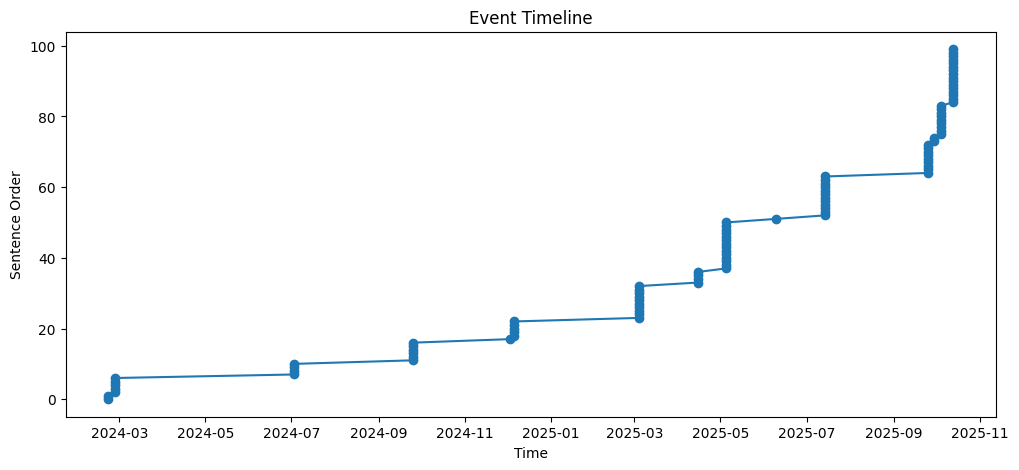

In [125]:
plt.figure(figsize=(12,5))

plt.plot(
    episode_df['published_date'],
    range(len(episode_df)),
    marker='o'
)

plt.title("Event Timeline")
plt.xlabel("Time")
plt.ylabel("Sentence Order")

plt.show()

## Event Clustering

In [126]:
import hdbscan

In [127]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=4,
    metric='euclidean'
)

event_labels = clusterer.fit_predict(episode_embeddings)

c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [128]:
episode_df["event_id"] = event_labels
episode_df.head()

,orig_index,content_id,sentence,published_date,category,episode,event_id
0,107,1289436,"Meanwhile, Fahmi said that for instance, he ha...",2024-02-22,5G,19,-1
1,1146,1289431,Malaysia has recorded almost million 5G servic...,2024-02-22,5G,19,-1
2,472,1292744,"""This is a good achievement but we are all awa...",2024-02-27,5G,19,0
3,471,1292744,"Meanwhile, Fahmi when met said that he had als...",2024-02-27,5G,19,-1
4,462,1292744,Malaysia has proven to the world that the appr...,2024-02-27,5G,19,0


In [129]:
print("Number of events detected:", len(set(event_labels)) - (1 if -1 in event_labels else 0))
print(episode_df["event_id"].value_counts())

Number of events detected: 3
-1    66
 0    15
 1    12
 2     7
Name: event_id, dtype: int64


In [130]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

reduced_embeddings = pca.fit_transform(episode_embeddings)

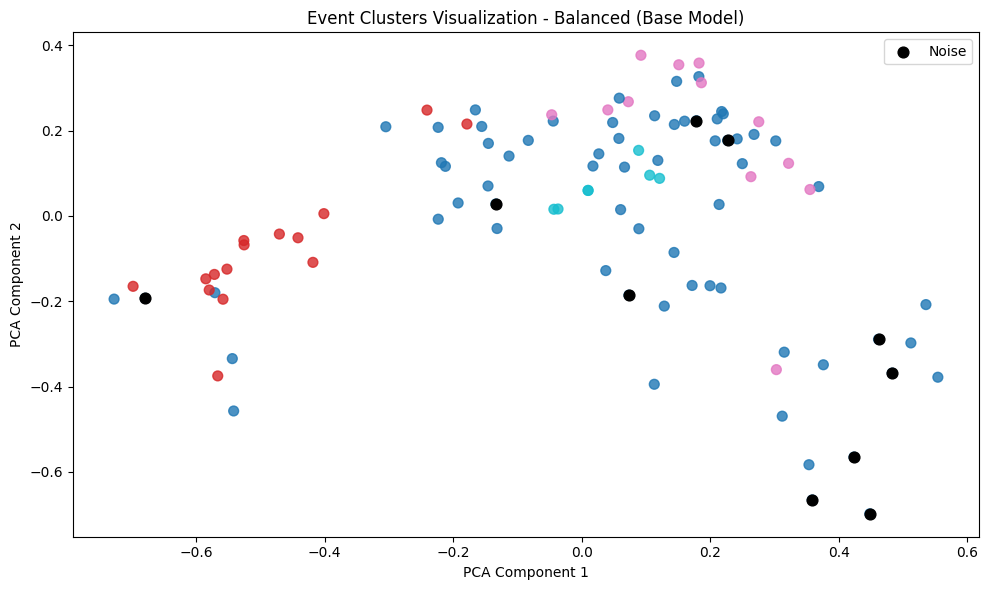

In [131]:
plt.style.use('default')
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    reduced_embeddings[:,0],
    reduced_embeddings[:,1],
    c=episode_df["event_id"],
    cmap="tab10",
    s=50,
    alpha=0.8,
)

noise_idx = np.where(event_labels == -1)[0]
noise_sample = np.random.choice(noise_idx, size=min(10, len(noise_idx)), replace=False)

plt.scatter(
    reduced_embeddings[noise_sample,0],
    reduced_embeddings[noise_sample,1],
    color="black",
    s=60,
    label="Noise"
)

plt.title("Event Clusters Visualization - Balanced (Base Model)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.legend()

plt.tight_layout()
plt.show()

## Event Labelling

In [132]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [133]:
def generate_event_tag(sentence):

    vectorizer = TfidfVectorizer(stop_words='english', max_features=8)
    
    X = vectorizer.fit_transform([sentence])
    
    keywords = vectorizer.get_feature_names_out()

    tag = " ".join(keywords)

    return tag

In [134]:
from sklearn.metrics.pairwise import cosine_similarity

In [135]:
import textwrap


episode_df["event_tag"] = ""

for event in episode_df["event_id"].unique():

    if event == -1:
        continue

    cluster = episode_df[episode_df["event_id"] == event]

    cluster_embeddings = episode_embeddings[cluster.index]

    centroid = cluster_embeddings.mean(axis=0)

    similarities = cosine_similarity([centroid], cluster_embeddings)[0]
    central_index = similarities.argmax()

    rep_sentence = cluster.iloc[central_index]["sentence"]
    
    wrapped = textwrap.fill(rep_sentence, width=100)
    
    print(f"\n==========Event {event}==========")
    print(f'"{wrapped}"\n')
    print("Similarity:", similarities.max())
    print(f"===========================")

    tag = generate_event_tag(rep_sentence)

    episode_df.loc[episode_df["event_id"] == event, "event_tag"] = tag


==========Event 0==========
"Communications Minister Fahmi Fadzil on Sept 17 said Malaysia has achieved 5G coverage in populated
areas across the country where a total of 7,191 5G sites have been developed nationwide, adding that
the government is committed towards expanding access."

Similarity: 0.9065703654849611

==========Event 1==========
"That’s why Tan believes the rollout of 5G could unlock new possibilities especially when it comes to
real-time data, automation, and large-scale monitoring."

Similarity: 0.8985983783419577

==========Event 2==========
"For 5G-enabled healthcare to flourish in Malaysia, Lin says there is a need to improve
infrastructure from end to end."

Similarity: 0.9482170463644186


In [136]:
event_tag_map = (
    episode_df
    .drop_duplicates(subset=["event_id"])
    .sort_values("event_id")[["event_id", "event_tag"]]
)

print(event_tag_map)

    event_id                                          event_tag
0         -1                                                   
2          0  17 5g malaysia minister nationwide populated s...
45         1  5g automation believes comes data especially l...
53         2  5g enabled end flourish healthcare improve inf...


In [137]:
for event in sorted(episode_df["event_id"].unique()):
    
    if event == -1:
        continue

    min_date = episode_df[episode_df["event_id"] == event]["published_date"].min().strftime("%d-%m-%Y")
    max_date = episode_df[episode_df["event_id"] == event]["published_date"].max().strftime("%d-%m-%Y")
    
    print("\n========================================================================================")
    print("Event ID:", event, "  {", list(event_tag_map.event_tag)[event+1],"}")
    print(f"Timeline: {min_date if min_date == max_date else f'{min_date} to {max_date}'}")
    print("========================================================================================")

    event_sentences = episode_df[episode_df["event_id"] == event]["sentence"].head(3)
    episode_df[episode_df["event_id"] == event].to_csv(fr"dataset\notFineTuned\events\balanced\eventID-{event}.csv",index=False)

    # for s in event_sentences:
    #     wrapped = textwrap.fill(s,width=100)
    #     print("-", wrapped)


Event ID: 0   { 17 5g malaysia minister nationwide populated said sept }
Timeline: 27-02-2024 to 04-03-2025

Event ID: 1   { 5g automation believes comes data especially large monitoring }
Timeline: 05-05-2025 to 13-10-2025

Event ID: 2   { 5g enabled end flourish healthcare improve infrastructure lin }
Timeline: 14-07-2025


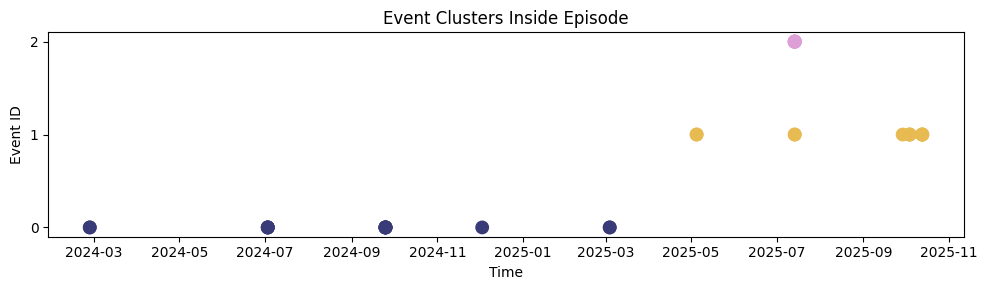

In [138]:
plt.figure(figsize=(10,3))

df_plot = episode_df[episode_df['event_id'] != -1]

plt.scatter(
    df_plot["published_date"],
    df_plot["event_id"],
    c=df_plot["event_id"],
    cmap="tab20b",
    s=80,
    alpha=1
)

plt.yticks(sorted(df_plot["event_id"].unique()))

plt.xlabel("Time")
plt.ylabel("Event ID")
plt.title("Event Clusters Inside Episode")

plt.tight_layout()
plt.show()